## Aim

In this code, different ways of getting ward data are checked. 

One way is to take the overall Bangalore network and then cut it with the command "[truncate by polygon](https://osmnx.readthedocs.io/en/stable/user-reference.html?utm_source=chatgpt.com#osmnx.truncate.truncate_graph_polygon)" in OSM. 

Another way is to use the function ox."[graph_from_polygon](https://osmnx.readthedocs.io/en/stable/user-reference.html?utm_source=chatgpt.com#osmnx.graph.graph_from_polygon)"

## Reading in the Python libraries

In [3]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [15]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

# directory to put some tests
TEST_DATA_DIR = DATA_DIR / "tests"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [9]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [10]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [11]:
G = ox.io.load_graphml(path_graphml)

In [26]:
# Select one ward: 50 - Gunjur
## ward_name = "50 - Gunjur"
ward_name = "48 - Panathur"

In [27]:
# Find the geometry
selected_ward = df[df['ward_name'] == ward_name]

In [28]:
selected_ward

,ward_id,ward_name,Corporatio,geometry
251,48,48 - Panathur,East,"POLYGON ((77.68927 12.94143, 77.68953 12.94158..."


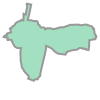

In [29]:
geom_selected = selected_ward.geometry.iloc[0]
geom_selected

## Select using graph from polygon

In [30]:
G_graph = ox.graph_from_polygon(
    geom_selected,
    simplify=True)

In [31]:
path_gpkg_bang = TEST_DATA_DIR /"test_from_polygon.gpkg"
print(path_gpkg_bang)
ox.io.save_graph_geopackage(G_graph, filepath=path_gpkg_bang)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\tests\test_from_polygon.gpkg


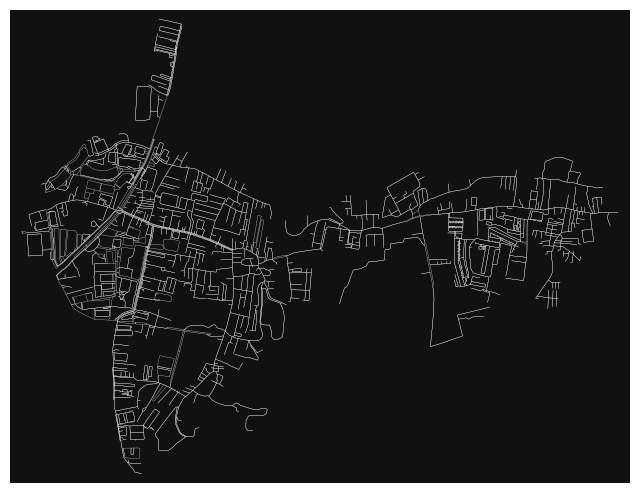

In [32]:
fig, ax = ox.plot_graph(G_graph, node_size=0, edge_color="w", edge_linewidth=0.2)

In [33]:
# https://blog.ouseful.info/2018/06/29/working-with-openstreetmap-roads-data-using-osmnx/
G_graph_2 = ox.graph_from_polygon(
    geom_selected,
    truncate_by_edge = True,
    simplify=True)

In [34]:
path_gpkg_bang = TEST_DATA_DIR /"test_from_polygon_truncate_by_edge.gpkg"
print(path_gpkg_bang)
ox.io.save_graph_geopackage(G_graph_2, filepath=path_gpkg_bang)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\tests\test_from_polygon_truncate_by_edge.gpkg


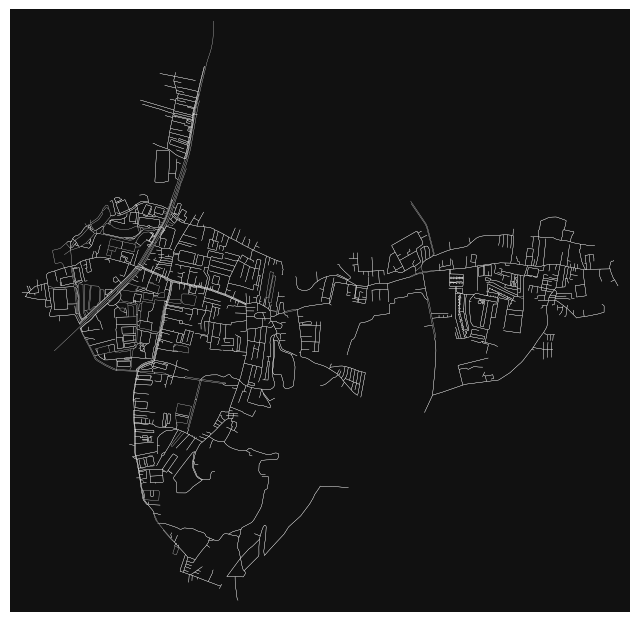

In [35]:
fig, ax = ox.plot_graph(G_graph_2, node_size=0, edge_color="w", edge_linewidth=0.2)

In [37]:
# https://blog.ouseful.info/2018/06/29/working-with-openstreetmap-roads-data-using-osmnx/
G_graph_3 = ox.graph_from_polygon(
    geom_selected,
    truncate_by_edge = True,
    retain_all = True,
    simplify=True)

In [38]:
path_gpkg_bang = TEST_DATA_DIR /"test_from_polygon_truncate_by_edge_retain_all.gpkg"
print(path_gpkg_bang)
ox.io.save_graph_geopackage(G_graph_3, filepath=path_gpkg_bang)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\tests\test_from_polygon_truncate_by_edge_retain_all.gpkg


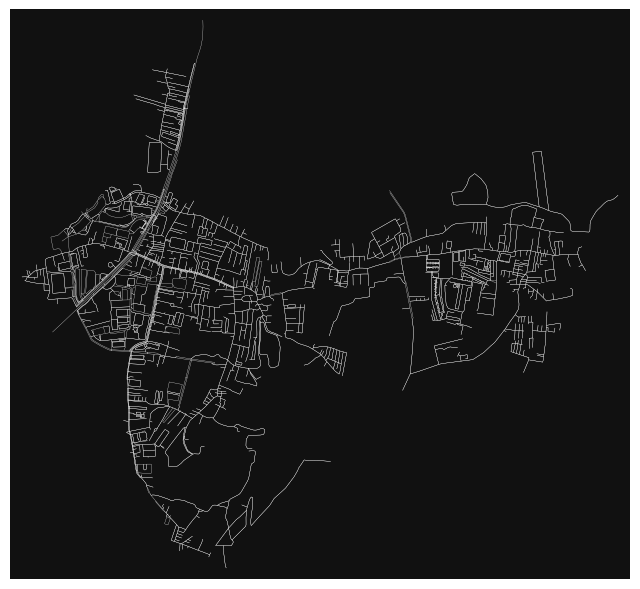

In [39]:
fig, ax = ox.plot_graph(G_graph_3, node_size=0, edge_color="w", edge_linewidth=0.2)

In [44]:
G_graph_4 = ox.graph_from_polygon(
    geom_selected,
    truncate_by_edge = False,
    retain_all = True,
    simplify=True)

In [45]:
path_gpkg_bang = TEST_DATA_DIR /"test_from_polygon_edge_retain_all.gpkg"
print(path_gpkg_bang)
ox.io.save_graph_geopackage(G_graph_4, filepath=path_gpkg_bang)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\tests\test_from_polygon_edge_retain_all.gpkg


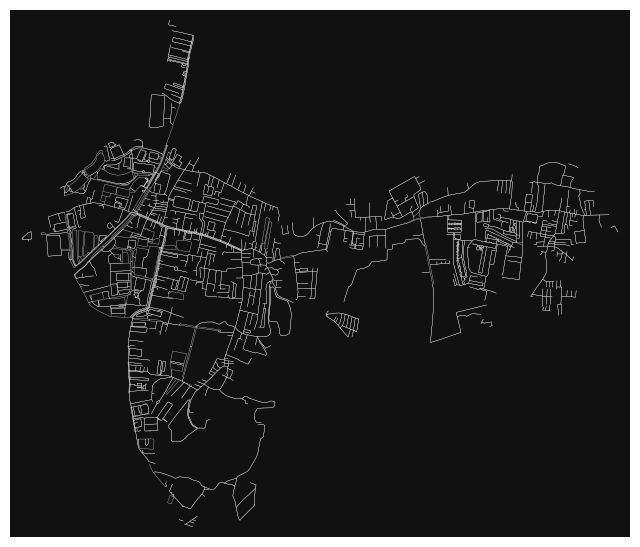

In [46]:
fig, ax = ox.plot_graph(G_graph_4, node_size=0, edge_color="w", edge_linewidth=0.2)

## Using truncate

In [40]:
 G_clipped = ox.truncate.truncate_graph_polygon(G, geom_selected)

In [41]:
path_gpkg_bang = TEST_DATA_DIR /"truncate_default.gpkg"
print(path_gpkg_bang)
ox.io.save_graph_geopackage(G_clipped, filepath=path_gpkg_bang)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\tests\truncate_default.gpkg


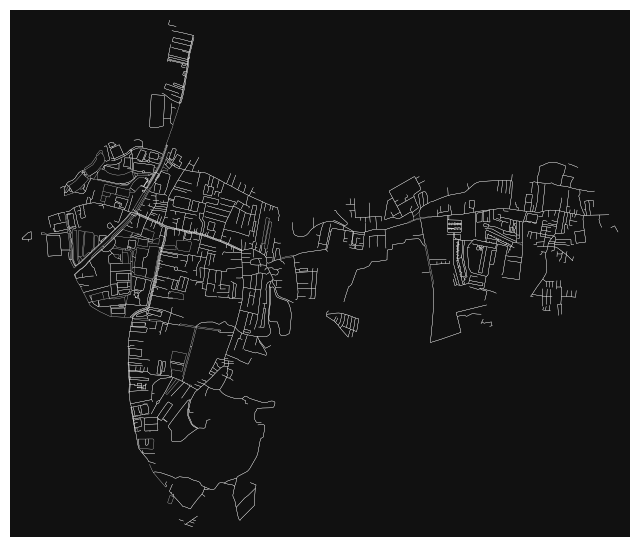

In [42]:
fig, ax = ox.plot_graph(G_clipped, node_size=0, edge_color="w", edge_linewidth=0.2)

Using the default truncate (when opening this in QGIS) seems to follow closest the truncate by edge False option for the 

In [48]:
G_clipped_2 = ox.truncate.truncate_graph_polygon(G, geom_selected, truncate_by_edge = True)

In [49]:
path_gpkg_bang = TEST_DATA_DIR /"truncate_truncate_by_edge.gpkg"
print(path_gpkg_bang)
ox.io.save_graph_geopackage(G_clipped_2, filepath=path_gpkg_bang)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\tests\truncate_truncate_by_edge.gpkg


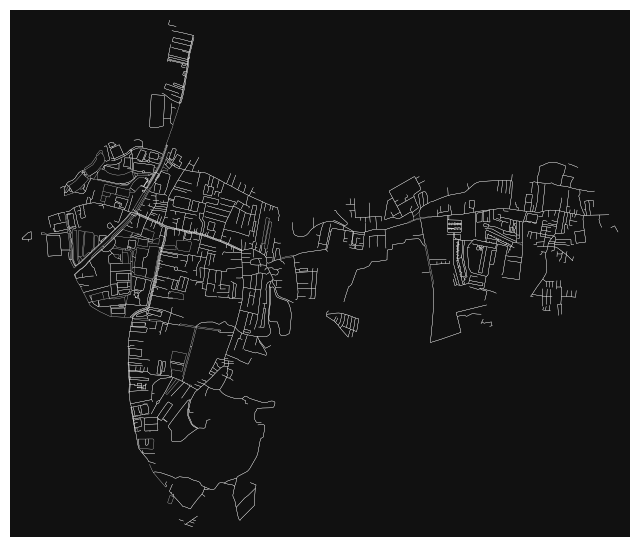

In [50]:
fig, ax = ox.plot_graph(G_clipped, node_size=0, edge_color="w", edge_linewidth=0.2)